In [1]:
from edge_sim_py.components.application import Application
from edge_sim_py.components.base_station import BaseStation
from edge_sim_py.components.container_image import ContainerImage
from edge_sim_py.components.container_layer import ContainerLayer
from edge_sim_py.components.container_registry import ContainerRegistry
from edge_sim_py.components.data_packet import DataPacket
from edge_sim_py.components.edge_server import EdgeServer
from edge_sim_py.components.network_flow import NetworkFlow
from edge_sim_py.components.network_link import NetworkLink
from edge_sim_py.components.network_switch import NetworkSwitch
from edge_sim_py.components.service import Service
from edge_sim_py.components.topology import Topology
from edge_sim_py.components.user import User
from edge_sim_py.dataset_generator.edge_servers import jetson_tx2
from edge_sim_py.dataset_generator.map import hexagonal_grid
from edge_sim_py.dataset_generator.network_switches import sample_switch
from edge_sim_py.dataset_generator.network_topologies import partially_connected_fullduplex_hexagonal_mesh
from edge_sim_py.components.user_access_patterns.circular_duration_and_interval_access_pattern import CircularDurationAndIntervalAccessPattern
from edge_sim_py.component_manager import ComponentManager

from visualization.plot_topology import plot_topology

In [ ]:
def reset_components():

    for cls in (
        Topology,
        NetworkLink,
        BaseStation,
        NetworkSwitch,
        EdgeServer,
        Service,
        User,
        Application,
        DataPacket,
        NetworkFlow,
        ContainerImage,
        ContainerLayer,
        ContainerRegistry,
    ):
        cls._instances = []
        cls._object_count = 0

In [3]:
def _servers_base_station(number_of_servers: int):

    if len(BaseStation.all()) < number_of_servers:
        raise Exception("Not enough base stations")

    # Connecting the edge server to a random base station with no attached edge server
    base_stations = sorted(BaseStation.all(), key=lambda b: b.id)

    step = len(base_stations) / number_of_servers

    for i in range(number_of_servers):
        index = int(i * step + step / 2)
        base_station = base_stations[index]

        server = jetson_tx2()
        base_station._connect_to_edge_server(server)

    return EdgeServer.all()


def _services_processing(number_of_services: int):

    for i in range(number_of_services):

        Service(
            obj_id=i,
            cpu_demand=1,
            memory_demand=1200,
            state=0,
            processing_time=2 + i,
            processing_output=21 + i,
            image_digest="sha256:a777c9c66ba177ccfea23f2a216ff6721e78a662cd17019488c417135299cd89",
        )

    return Service.all()

In [ ]:
reset_components()

# Creating the map coordinates
map_coordinates = hexagonal_grid(x_size=3, y_size=3)

# Creating the Base Stations and Network Switches
# For every map coordinate 1 Base Station and 1 Network Switch
for coordinates in map_coordinates:

    base_station = BaseStation()
    base_station.wireless_delay = 0
    base_station.coordinates = coordinates

    network_switch = sample_switch()
    base_station._connect_to_network_switch(network_switch=network_switch)

# Creating Network Links and Topology
topology = partially_connected_fullduplex_hexagonal_mesh(
    network_nodes=NetworkSwitch.all(),
    link_specifications=[
        {"number_of_objects": 16, "delay": 1, "bandwidth": 10},
    ],
)

# Creating the Edge Server
servers = _servers_base_station(number_of_servers=4)

# Creating the services
services = _services_processing(number_of_services=4)

# Assigning the services to the edge servers
for server, service in zip(servers, services):
    server.services.append(service)
    service.server = server
    service._available = True

# Creating users
def static_dummy_mobility(user):
    user.coordinates_trace.append(user.coordinates)

user1 = User()
user1.set_packet_size_strategy(mode="fixed", size=20)
user1._set_initial_position(coordinates=(0, 0))
user1.mobility_model = static_dummy_mobility

user2 = User()
user2.set_packet_size_strategy(mode="fixed", size=20)
user2._set_initial_position(coordinates=(4, 0))
user2.mobility_model = static_dummy_mobility

# Creating applications
app1 = Application()
ordered_services = sorted(services, key=lambda s: s.id)
for service in ordered_services:
    app1.connect_to_service(service=service)

app2 = Application()
descending_services = sorted(services, key=lambda s: s.id, reverse=True)
for service in descending_services:
    app2.connect_to_service(service=service)

CircularDurationAndIntervalAccessPattern(user=user1, app=app1, start=1, duration_values=[1], interval_values=[100])
CircularDurationAndIntervalAccessPattern(user=user2, app=app2, start=1, duration_values=[1], interval_values=[100])
user1._connect_to_application(app=app1, delay_sla=6)  # sla defined with only propagation delay
user2._connect_to_application(app=app2, delay_sla=7)  # sla defined with only propagation delay

In [5]:
# 2 static user 
# 2 app
# services provisioned
dataset = ComponentManager.export_scenario(save_to_file=True, file_name="dataset1")

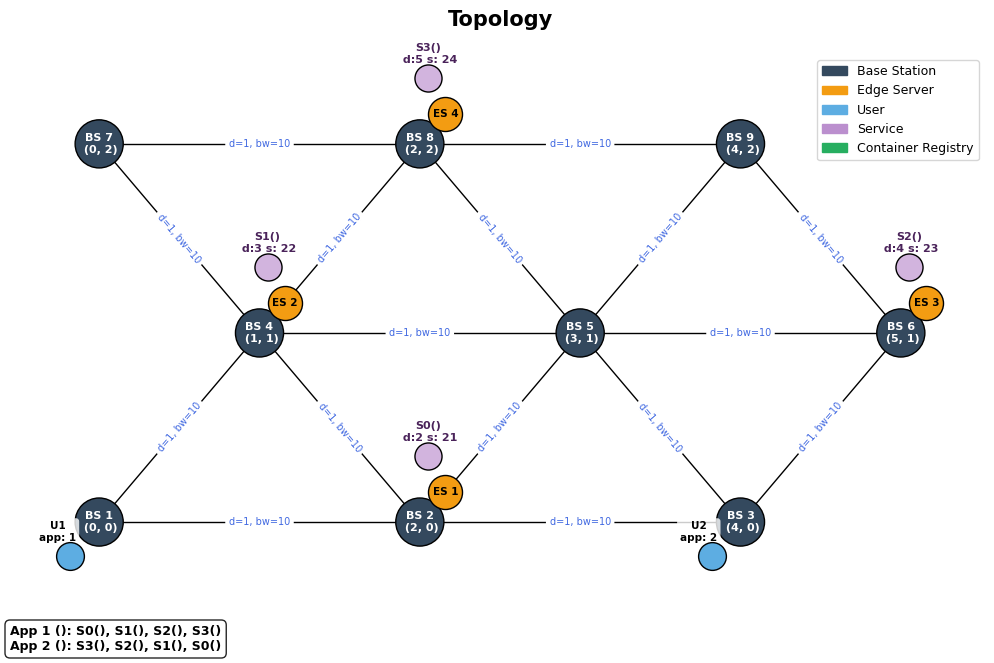

In [6]:
plot_topology()